In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import librosa

from scipy.signal import butter, filtfilt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    matthews_corrcoef,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate
from sklearn.pipeline import make_pipeline

In [ ]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import onnxruntime as ort
from onnxruntime.quantization import quantize_dynamic, QuantType

In [2]:
#defining constants from config

SAMPLE_RATE = 22050
BANDPASS_LOWCUT = 50
BANDPASS_HIGHCUT = 1000
BANDPASS_ORDER = 5

# functions for filtering and feature extraction

def bandpass_filter(signal, sr, lowcut, highcut, order=5):
    nyq = 0.5 * sr
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

def extract_features(signal, sr=SAMPLE_RATE):
    try:
        mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=13)
        return np.mean(mfccs.T, axis=0)
    except Exception as e:
        print(f"Feature extraction failed: {e}")
        return None

#loading datat & preprocessing 

def load_data(folder_path, vessel_keyword):
    X, y, filenames = [], [], []
    for fname in os.listdir(folder_path):
        if fname.endswith(".wav"):
            label = 1 if vessel_keyword in fname else 0
            try:
                filepath = os.path.join(folder_path, fname)
                y_raw, sr = librosa.load(filepath, sr=SAMPLE_RATE)
                y_filtered = bandpass_filter(y_raw, sr, BANDPASS_LOWCUT, BANDPASS_HIGHCUT, BANDPASS_ORDER)
                feat = extract_features(y_filtered, sr)
                if feat is not None:
                    X.append(feat)
                    y.append(label)
                    filenames.append(fname)
            except Exception as e:
                print(f"Failed to process {fname}: {e}")
    return np.array(X), np.array(y), filenames

 Loading data...


C:\Users\annaf\AppData\Local\Temp\ipykernel_34252\2707765885.py:34: UserWarning: PySoundFile failed. Trying audioread instead.
  y_raw, sr = librosa.load(filepath, sr=SAMPLE_RATE)
C:\Users\annaf\miniconda3\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Failed to process 20220624111353_S_No7_F_W_0_label__0__5_1.wav: 
 Splitting data...
Scaling features...
 Training Random Forest...
 Evaluation:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00        71

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



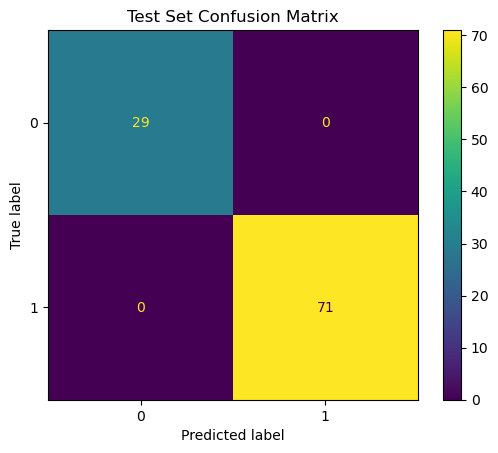

In [3]:
#preprocessing, training & evaluation

if __name__ == "__main__":
    data_folder = r"D:/DAEN 690/QiandaoEar22/QiandaoEarSubset"
    keyword = "No7"  # Change this to your vessel of interest

    print(" Loading data...")
    X, y, filenames = load_data(data_folder, keyword)

    print(" Splitting data...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

    print("Scaling features...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(" Training Random Forest...")
    random_forest_model = RandomForestClassifier(n_estimators=100,max_depth=10,min_samples_leaf=5,class_weight='balanced', random_state=42)
    random_forest_model.fit(X_train_scaled, y_train)

    print(" Evaluation:")
    y_pred = random_forest_model.predict(X_test_scaled)
    print(classification_report(y_test, y_pred))
    
ConfusionMatrixDisplay.from_estimator(random_forest_model, X_test_scaled, y_test)
plt.title("Test Set Confusion Matrix")
plt.show()

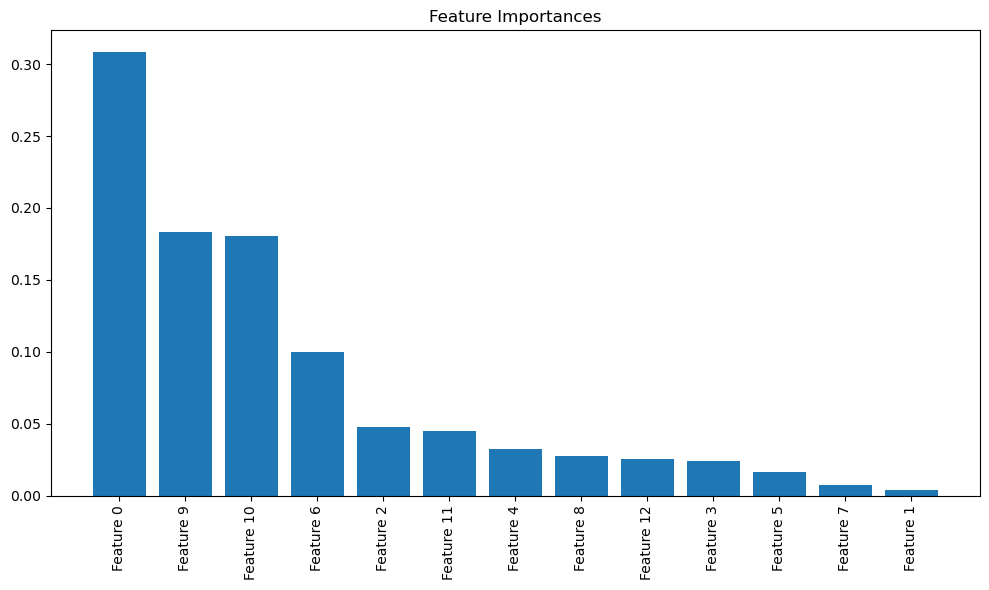

In [4]:
#visualizing rf:
    
feature_names = X.columns if hasattr(X, "columns") else [f"Feature {i}" for i in range(X.shape[1])]
importances = random_forest_model.feature_importances_
indices = np.argsort(importances)[::-1]  # descending order

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=90)
plt.tight_layout()
plt.show()

In [5]:
#checking for overfitting 

print("Train accuracy:", random_forest_model.score(X_train_scaled, y_train))

print("Test accuracy:", random_forest_model.score(X_test_scaled, y_test))


#cross-validation for overfitting 
random_forest_model = RandomForestClassifier(n_estimators=100,max_depth=10,min_samples_leaf=5, class_weight='balanced',random_state=42)

# StratifiedKFold preserves class distribution in splits
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Run cross-validation with accuracy scoring
scores = cross_val_score(random_forest_model, X, y, cv=cv, scoring='accuracy')

print("Cross-validation accuracy scores:", scores)
print("Mean accuracy:", np.mean(scores))
print("Standard deviation:", np.std(scores))

Train accuracy: 1.0
Test accuracy: 1.0
Cross-validation accuracy scores: [1.         1.         1.         0.97979798 0.97979798]
Mean accuracy: 0.9919191919191919
Standard deviation: 0.009896928253669416


In [6]:
#cross validtaion with multiple metrics 

# Create a pipeline that scales and then classifies
pipeline = make_pipeline(StandardScaler(), random_forest_model)

scoring = ['accuracy', 'precision', 'recall', 'f1']

cv_results = cross_validate(pipeline, X, y, cv=5, scoring=scoring)

for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric.capitalize()} scores: {scores}")
    print(f"Mean {metric}: {np.mean(scores):.4f}")
    print(f"Std {metric}: {np.std(scores):.4f}")
    print()

Accuracy scores: [0.91       0.98       1.         1.         0.96969697]
Mean accuracy: 0.9719
Std accuracy: 0.0331

Precision scores: [1.         0.97260274 1.         1.         1.        ]
Mean precision: 0.9945
Std precision: 0.0110

Recall scores: [0.875      1.         1.         1.         0.95774648]
Mean recall: 0.9665
Std recall: 0.0486

F1 scores: [0.93333333 0.98611111 1.         1.         0.97841727]
Mean f1: 0.9796
Std f1: 0.0246



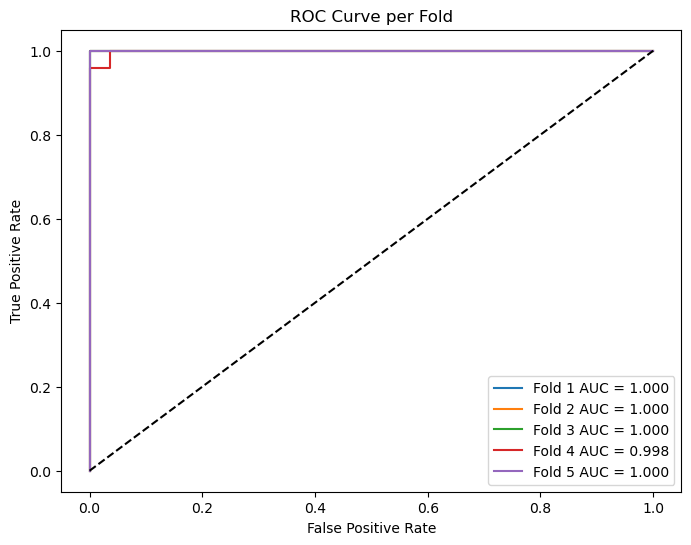

In [7]:
#roc curve 

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
plt.figure(figsize=(8,6))

for i, (train_idx, test_idx) in enumerate(cv.split(X, y)):
    pipeline.fit(X[train_idx], y[train_idx])
    y_proba = pipeline.predict_proba(X[test_idx])[:, 1]
    fpr, tpr, _ = roc_curve(y[test_idx], y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Fold {i+1} AUC = {roc_auc:.3f}')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve per Fold')
plt.legend()
plt.show()

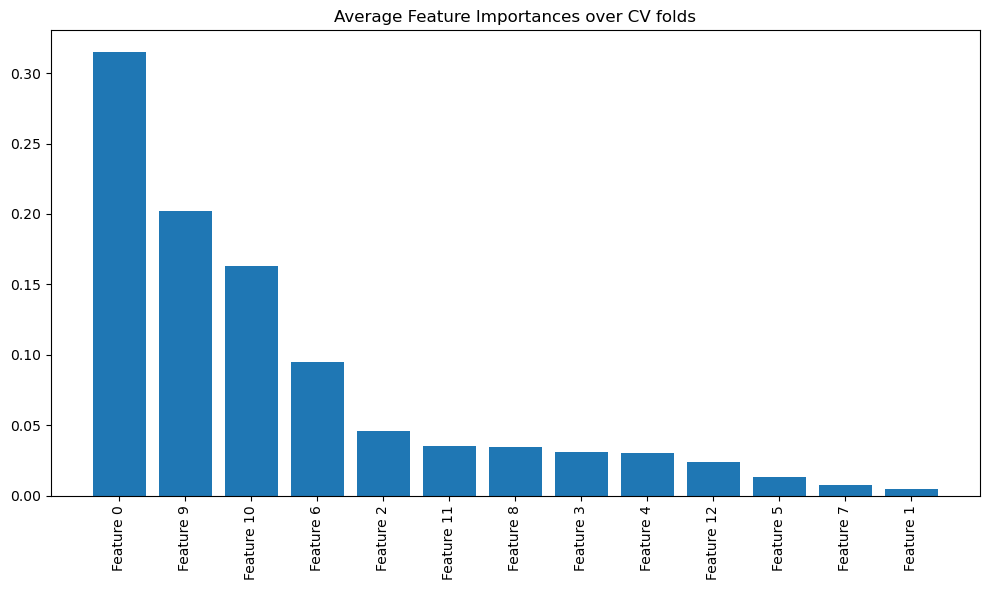

In [8]:
#feature importnace across folds
importances = np.zeros(X.shape[1])
for train_idx, test_idx in cv.split(X, y):
    pipeline.fit(X[train_idx], y[train_idx])
    importances += pipeline.named_steps['randomforestclassifier'].feature_importances_

importances /= cv.get_n_splits()
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.title("Average Feature Importances over CV folds")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), [f"Feature {i}" for i in indices], rotation=90)
plt.tight_layout()
plt.show()

## Quantization technique

Convert to ONNX

In [10]:
initial_type= [('input', FloatTensorType([None, X_train.shape[1]]))]
onnx_model= convert_sklearn(random_forest_model, initial_types= initial_type)

#save the model
with open('rf_model.onnx', 'wb') as f:
    f.write(onnx_model.SerializeToString())

In [16]:
# quantize the model to int8 (dynamic quantization)
quantize_dynamic(
    model_input= 'rf_model.onnx',
    model_output= 'rf_model_quantized.onnx',
    weight_type= QuantType.QInt8
)

print("Model quantized and saved")

Model quantized and saved


In [19]:
# run and evaluate the quantized ONNX model
session = ort.InferenceSession('rf_model_quantized.onnx')

#get input and output names
input_name= session.get_inputs()[0].name
output_name= session.get_outputs()[0].name

# run inference
onnx_preds= session.run([output_name], {input_name: X_test.astype(np.float32)})[0]

# evaluate
accuracy= accuracy_score(y_test, onnx_preds)
precision= precision_score(y_test, onnx_preds, average= 'weighted', zero_division=0)
recall= recall_score(y_test, onnx_preds, average= 'weighted', zero_division= 0)
f1= f1_score(y_test, onnx_preds, average= 'weighted', zero_division=0)

#print
print(f'Quantized Model Accuracy: {accuracy:.4f}')
print(f'Quantized Model Precision: {precision:.4f}')
print(f'Quantized Model Recall: {recall:.4f}')
print(f'Quantized Model F1-score: {f1:.4f}')

Quantized Model Accuracy: 0.7100
Quantized Model Precision: 0.5041
Quantized Model Recall: 0.7100
Quantized Model F1-score: 0.5896
